## 0. Imports

In [32]:
# ============================================================
# 0. Imports
# ============================================================
import math
import random
import pickle
from pathlib import Path
from collections import deque
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

## 1. Configuration

In [33]:
# ============================================================
# 1. Configuration
# ============================================================
NODES_CSV = "output/processed_fishtree_nodes.csv"
EDGE_INDEX_NPY = "output/processed_fishtree_edge_index.npy"
EDGE_WEIGHT_NPY = "output/processed_fishtree_edge_weight.npy"

# Preprocessed band index file
BAND_INDEX_PATH = "distance_band_index.pkl"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model
EMB_DIM = 256
LR = 1e-5
WEIGHT_DECAY = 1e-5

# Training
NUM_STEPS = 100_000
BATCH_SIZE = 256

# Loss
LAMBDA_PAIR = 1.0

# Tree / LCA
ROOT_NODE = 0

# Distance binning
NUM_DISTANCE_BINS = 100          # regular equal-width bins
CLIP_DIST_PERCENTILE = 95.0      # distances above this go into overflow bin

# Sampling mixture
SAMPLING_MIX = {
    "same_bin": 0.40,
    "adjacent_bin": 0.25,
    "local_vs_medium": 0.20,
    "medium_vs_far": 0.15,
}

# Bin-region split over regular bins (excluding overflow)
LOCAL_BIN_FRACTION = 0.15
MEDIUM_BIN_FRACTION = 0.50
# far = everything above medium

# Evaluation
EVAL_NUM_PAIR_SAMPLES = 10000
EVAL_NUM_ANCHORS = 200
EVAL_CANDIDATE_SIZE = 2000

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

Using device: cuda


## 2. Load the preprocessed tree

In [34]:
# ============================================================
# 2. Load tree files
# ============================================================
nodes_df = pd.read_csv(NODES_CSV)
edge_index = np.load(EDGE_INDEX_NPY)
edge_weight = np.load(EDGE_WEIGHT_NPY)

num_nodes = len(nodes_df)

print("num_nodes:", num_nodes)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

nodes_df.head()

num_nodes: 22919
edge_index shape: (2, 45836)
edge_weight shape: (45836,)


,node_id,node_name,is_leaf,species
0,0,internal_0,False,NaN
1,1,internal_1,False,NaN
2,2,internal_2,False,NaN
3,3,internal_3,False,NaN
4,4,internal_4,False,NaN


## 3. Build adjacency list

In [35]:
# ============================================================
# 3. Build adjacency list
# ============================================================
adj = [[] for _ in range(num_nodes)]

src = edge_index[0]
dst = edge_index[1]

for u, v, w in zip(src, dst, edge_weight):
    u = int(u)
    v = int(v)
    w = float(w)
    adj[u].append((v, w))

degrees = np.array([len(nei) for nei in adj])
print("min degree:", degrees.min())
print("max degree:", degrees.max())
print("mean degree:", degrees.mean())

min degree: 1
max degree: 3
mean degree: 1.999912736157773


## 4. LCA preprocessing for exact weighted distances

In [36]:
# ============================================================
# 4. LCA preprocessing
# ============================================================
def preprocess_lca(adj, root=0):
    n = len(adj)
    LOG = math.ceil(math.log2(max(2, n))) + 1

    parent = np.full((LOG, n), -1, dtype=np.int64)
    depth_edges = np.full(n, -1, dtype=np.int64)
    depth_weight = np.zeros(n, dtype=np.float64)

    depth_edges[root] = 0
    q = deque([root])

    while q:
        u = q.popleft()
        for v, w in adj[u]:
            if depth_edges[v] != -1:
                continue
            depth_edges[v] = depth_edges[u] + 1
            depth_weight[v] = depth_weight[u] + w
            parent[0, v] = u
            q.append(v)

    for k in range(1, LOG):
        for v in range(n):
            p = parent[k - 1, v]
            parent[k, v] = -1 if p == -1 else parent[k - 1, p]

    return parent, depth_edges, depth_weight


def lca(u, v, parent, depth_edges):
    if depth_edges[u] < depth_edges[v]:
        u, v = v, u

    LOG = parent.shape[0]

    diff = depth_edges[u] - depth_edges[v]
    for k in range(LOG):
        if diff & (1 << k):
            u = parent[k, u]

    if u == v:
        return u

    for k in reversed(range(LOG)):
        pu = parent[k, u]
        pv = parent[k, v]
        if pu != pv:
            u = pu
            v = pv

    return parent[0, u]


def tree_distance(u, v, parent, depth_edges, depth_weight):
    a = lca(u, v, parent, depth_edges)
    return depth_weight[u] + depth_weight[v] - 2.0 * depth_weight[a]

In [37]:
parent, depth_edges, depth_weight = preprocess_lca(adj, root=ROOT_NODE)

print("LCA table shape:", parent.shape)
print("Connected check:", np.all(depth_edges >= 0))
print("Max edge depth:", depth_edges.max())
print("Max weighted depth:", depth_weight.max())

LCA table shape: (16, 22919)
Connected check: True
Max edge depth: 65
Max weighted depth: 4.30323304515332


## 5. Node-type masks

In [38]:
# ============================================================
# 5. Node-type masks
# ============================================================
is_leaf = nodes_df["is_leaf"].astype(bool).to_numpy()
leaf_ids = np.where(is_leaf)[0]
internal_ids = np.where(~is_leaf)[0]

print("num leaves:", len(leaf_ids))
print("num internal:", len(internal_ids))

num leaves: 11460
num internal: 11459


## 6. Estimate a global distance scale for the pairwise target

In [39]:
# ============================================================
# 6. Estimate global distance scale tau
# ============================================================
def estimate_tau(num_samples=50_000):
    dists = []
    for _ in range(num_samples):
        u = random.randrange(num_nodes)
        v = random.randrange(num_nodes)
        if u == v:
            continue
        dists.append(tree_distance(u, v, parent, depth_edges, depth_weight))
    return float(np.median(dists))

tau = estimate_tau()
print("Estimated tau:", tau)

Estimated tau: 2.23281579464674


## 7. Estimate clipping distance for equal-width bins

In [40]:
# ============================================================
# 7. Estimate clipping distance for equal-width bins
# ============================================================
def sample_tree_distance_distribution(num_samples=50_000):
    dists = []
    for _ in range(num_samples):
        u = random.randrange(num_nodes)
        v = random.randrange(num_nodes)
        if u == v:
            continue
        dists.append(tree_distance(u, v, parent, depth_edges, depth_weight))
    return np.array(dists, dtype=np.float64)

dist_samples = sample_tree_distance_distribution()
clip_distance = float(np.percentile(dist_samples, CLIP_DIST_PERCENTILE))

print("Distance percentiles:")
for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"p{q:2d} = {np.percentile(dist_samples, q):.4f}")

print("clip_distance:", clip_distance)

Distance percentiles:
p 1 = 0.3641
p 5 = 0.7269
p10 = 0.9312
p25 = 1.3665
p50 = 2.2436
p75 = 3.0097
p90 = 3.3123
p95 = 3.5262
p99 = 4.0037
clip_distance: 3.526211174345093


## 8. Build per-anchor distance-band index

In [41]:
# ============================================================
# 8. Build per-anchor distance-band index
# ============================================================
def get_bin_index(distance, clip_distance, num_regular_bins):
    """
    Returns:
        0 .. num_regular_bins-1 for regular bins
        num_regular_bins for overflow bin
    """
    if distance > clip_distance:
        return num_regular_bins  # overflow

    # map [0, clip_distance] to regular bins
    frac = distance / clip_distance
    idx = int(frac * num_regular_bins)

    if idx == num_regular_bins:
        idx = num_regular_bins - 1

    return idx

In [42]:
def build_distance_band_index(
    num_nodes,
    parent,
    depth_edges,
    depth_weight,
    clip_distance,
    num_regular_bins,
):
    """
    Returns a dictionary with:
      - anchor_bins: list of length num_nodes
          each item is a list of length (num_regular_bins + 1),
          where each bin is a dict with:
              {
                  "node_ids": np.ndarray[int64],
                  "distances": np.ndarray[float32]
              }
      - bin_edges
      - clip_distance
      - num_regular_bins
    """
    total_bins = num_regular_bins + 1  # includes overflow
    anchor_bins = []

    for u in tqdm(range(num_nodes)):
        per_bin = [[] for _ in range(total_bins)]

        for v in range(num_nodes):
            if v == u:
                continue

            d = tree_distance(u, v, parent, depth_edges, depth_weight)
            b = get_bin_index(d, clip_distance, num_regular_bins)
            per_bin[b].append((v, d))

        # sort inside each bin by exact distance
        packed_bins = []
        for items in per_bin:
            items.sort(key=lambda x: x[1])

            node_ids = np.array([x[0] for x in items], dtype=np.int64)
            distances = np.array([x[1] for x in items], dtype=np.float32)

            packed_bins.append({
                "node_ids": node_ids,
                "distances": distances,
            })

        anchor_bins.append(packed_bins)


    bin_edges = np.linspace(0.0, clip_distance, num_regular_bins + 1, dtype=np.float32)

    return {
        "anchor_bins": anchor_bins,
        "bin_edges": bin_edges,
        "clip_distance": float(clip_distance),
        "num_regular_bins": int(num_regular_bins),
        "num_total_bins": int(total_bins),
    }

In [43]:
# ============================================================
# 8b. Build or load band index
# ============================================================
band_index_path = Path(BAND_INDEX_PATH)

if band_index_path.exists():
    print("Loading existing band index from disk...")
    with open(band_index_path, "rb") as f:
        band_index = pickle.load(f)
else:
    print("Building new band index...")
    band_index = build_distance_band_index(
        num_nodes=num_nodes,
        parent=parent,
        depth_edges=depth_edges,
        depth_weight=depth_weight,
        clip_distance=clip_distance,
        num_regular_bins=NUM_DISTANCE_BINS,
    )

    with open(band_index_path, "wb") as f:
        pickle.dump(band_index, f)

    print(f"Saved band index to: {band_index_path}")

Loading existing band index from disk...


## 9. Inspect bin occupancy

In [44]:
# ============================================================
# 9. Inspect bin occupancy
# ============================================================
def inspect_bin_occupancy(band_index, num_show=15):
    anchor_bins = band_index["anchor_bins"]
    total_bins = band_index["num_total_bins"]

    occupancies = np.zeros((len(anchor_bins), total_bins), dtype=np.int32)

    for u in range(len(anchor_bins)):
        for b in range(total_bins):
            occupancies[u, b] = len(anchor_bins[u][b]["node_ids"])

    mean_occ = occupancies.mean(axis=0)
    med_occ = np.median(occupancies, axis=0)

    print("Mean occupancy per bin:")
    print(mean_occ[:num_show], "...")

    print("Median occupancy per bin:")
    print(med_occ[:num_show], "...")

    print("Overflow mean occupancy:", mean_occ[-1])

    return occupancies

occupancies = inspect_bin_occupancy(band_index)

Mean occupancy per bin:
[ 5.98821938  9.14987565 14.72385357 18.58562765 21.17474584 23.14350539
 26.39547973 30.10462935 33.86936603 37.09934988 42.91190715 49.29639164
 57.30215105 67.88961124 77.42170252] ...
Median occupancy per bin:
[ 2.  3.  4.  6.  8.  9. 10. 11. 12. 13. 15. 18. 21. 25. 27.] ...
Overflow mean occupancy: 1125.5762467821457


## 10. Define bin regions for multi-scale sampling

In [45]:
# ============================================================
# 10. Bin regions
# ============================================================
num_regular_bins = band_index["num_regular_bins"]
overflow_bin = num_regular_bins

local_end = max(1, int(num_regular_bins * LOCAL_BIN_FRACTION))
medium_end = max(local_end + 1, int(num_regular_bins * MEDIUM_BIN_FRACTION))

local_bins = list(range(0, local_end))
medium_bins = list(range(local_end, medium_end))
far_bins = list(range(medium_end, num_regular_bins))
all_regular_bins = list(range(num_regular_bins))

print("num_regular_bins:", num_regular_bins)
print("local bins:", (local_bins[0], local_bins[-1]) if local_bins else None)
print("medium bins:", (medium_bins[0], medium_bins[-1]) if medium_bins else None)
print("far bins:", (far_bins[0], far_bins[-1]) if far_bins else None)
print("overflow bin:", overflow_bin)

num_regular_bins: 100
local bins: (0, 14)
medium bins: (15, 49)
far bins: (50, 99)
overflow bin: 100


## 11. Model

In [46]:
# ============================================================
# 11. Model
# ============================================================
class NodeEmbeddingModel(nn.Module):
    def __init__(self, num_nodes, emb_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, node_ids):
        z = self.embedding(node_ids)
        z = F.normalize(z, p=2, dim=-1)
        return z

    def get_all_embeddings(self):
        z = self.embedding.weight
        z = F.normalize(z, p=2, dim=-1)
        return z

## 12. Multi-scale distance-band sampler

In [47]:
# ============================================================
# 12. Multi-scale distance-band sampler
# ============================================================
class MultiScaleDistanceBandSampler:
    def __init__(
        self,
        band_index,
        parent,
        depth_edges,
        depth_weight,
        local_bins,
        medium_bins,
        far_bins,
        overflow_bin,
        num_nodes,
    ):
        self.band_index = band_index
        self.anchor_bins = band_index["anchor_bins"]

        self.parent = parent
        self.depth_edges = depth_edges
        self.depth_weight = depth_weight

        self.local_bins = local_bins
        self.medium_bins = medium_bins
        self.far_bins = far_bins
        self.overflow_bin = overflow_bin
        self.num_nodes = num_nodes

        self.num_regular_bins = band_index["num_regular_bins"]
        self.num_total_bins = band_index["num_total_bins"]

        # Bias positive-bin sampling toward small bins
        self.regular_bin_probs = self._make_positive_bin_probs()

        self.triplet_type_names = list(SAMPLING_MIX.keys())
        self.triplet_type_probs = np.array(list(SAMPLING_MIX.values()), dtype=np.float64)
        self.triplet_type_probs = self.triplet_type_probs / self.triplet_type_probs.sum()

    def _make_positive_bin_probs(self):
        # Inverse-like decay over regular bins
        weights = np.array([1.0 / (1.0 + b) for b in range(self.num_regular_bins)], dtype=np.float64)
        weights /= weights.sum()
        return weights

    def dist(self, u, v):
        return tree_distance(u, v, self.parent, self.depth_edges, self.depth_weight)

    def _choose_anchor(self):
        return random.randrange(self.num_nodes)

    def _get_bin_node_ids(self, anchor, b):
        return self.anchor_bins[anchor][b]["node_ids"]

    def _get_bin_distances(self, anchor, b):
        return self.anchor_bins[anchor][b]["distances"]

    def _sample_nonempty_bin(self, anchor, candidate_bins, weighted=False, max_tries=100):
        valid_bins = [b for b in candidate_bins if len(self._get_bin_node_ids(anchor, b)) > 0]
        if not valid_bins:
            return None

        if weighted:
            weights = np.array([self.regular_bin_probs[b] if b < self.num_regular_bins else 1e-6 for b in valid_bins], dtype=np.float64)
            if weights.sum() == 0:
                weights = np.ones(len(valid_bins), dtype=np.float64)
            weights /= weights.sum()
            return int(np.random.choice(valid_bins, p=weights))
        else:
            return int(random.choice(valid_bins))

    def _sample_from_bin_uniform(self, anchor, b):
        node_ids = self._get_bin_node_ids(anchor, b)
        distances = self._get_bin_distances(anchor, b)

        if len(node_ids) == 0:
            return None

        idx = random.randrange(len(node_ids))
        return int(node_ids[idx]), float(distances[idx]), idx

    def _sample_same_bin_ordered_pair(self, anchor, b):
        """
        Sample positive and negative from the same bin such that negative is farther.
        Since distances are sorted ascending, sample i < j.
        """
        node_ids = self._get_bin_node_ids(anchor, b)
        distances = self._get_bin_distances(anchor, b)

        if len(node_ids) < 2:
            return None

        i = random.randrange(len(node_ids) - 1)
        j = random.randrange(i + 1, len(node_ids))

        v = int(node_ids[i])
        w = int(node_ids[j])
        d_uv = float(distances[i])
        d_uw = float(distances[j])

        if d_uv < d_uw:
            return v, w, d_uv, d_uw

        return None

    def _sample_adjacent_bin_pair(self, anchor):
        """
        Pick bin i and i+1, sample positive from i and negative from i+1.
        """
        valid_i = []
        for i in range(self.num_regular_bins - 1):
            if len(self._get_bin_node_ids(anchor, i)) > 0 and len(self._get_bin_node_ids(anchor, i + 1)) > 0:
                valid_i.append(i)

        if not valid_i:
            return None

        # bias toward smaller i
        weights = np.array([self.regular_bin_probs[i] for i in valid_i], dtype=np.float64)
        weights /= weights.sum()
        i = int(np.random.choice(valid_i, p=weights))

        pos = self._sample_from_bin_uniform(anchor, i)
        neg = self._sample_from_bin_uniform(anchor, i + 1)
        if pos is None or neg is None:
            return None

        v, d_uv, _ = pos
        w, d_uw, _ = neg

        if d_uv < d_uw:
            return v, w, d_uv, d_uw

        # fallback to exact check
        if d_uv == d_uw:
            return None

        if d_uv > d_uw:
            return w, v, d_uw, d_uv

        return None

    def _sample_cross_region_pair(self, anchor, pos_bins, neg_bins, pos_weighted=True, neg_weighted=False):
        pos_bin = self._sample_nonempty_bin(anchor, pos_bins, weighted=pos_weighted)
        if pos_bin is None:
            return None

        valid_neg_bins = [b for b in neg_bins if b >= pos_bin and len(self._get_bin_node_ids(anchor, b)) > 0]
        if not valid_neg_bins:
            return None

        neg_bin = self._sample_nonempty_bin(anchor, valid_neg_bins, weighted=neg_weighted)
        if neg_bin is None:
            return None

        if neg_bin == pos_bin:
            same = self._sample_same_bin_ordered_pair(anchor, pos_bin)
            if same is None:
                return None
            v, w, d_uv, d_uw = same
            return v, w, d_uv, d_uw

        pos = self._sample_from_bin_uniform(anchor, pos_bin)
        neg = self._sample_from_bin_uniform(anchor, neg_bin)
        if pos is None or neg is None:
            return None

        v, d_uv, _ = pos
        w, d_uw, _ = neg

        # Use exact distances if ordering somehow flips
        if d_uv == d_uw:
            d_uv = self.dist(anchor, v)
            d_uw = self.dist(anchor, w)

        if d_uv < d_uw:
            return v, w, d_uv, d_uw
        elif d_uv > d_uw:
            return w, v, d_uw, d_uv
        else:
            return None

    def sample_triplet(self, max_anchor_tries=100):
        for _ in range(max_anchor_tries):
            anchor = self._choose_anchor()
            triplet_type = np.random.choice(self.triplet_type_names, p=self.triplet_type_probs)

            if triplet_type == "same_bin":
                b = self._sample_nonempty_bin(anchor, self.local_bins + self.medium_bins, weighted=True)
                if b is None:
                    continue
                same = self._sample_same_bin_ordered_pair(anchor, b)
                if same is None:
                    continue
                v, w, d_uv, d_uw = same
                return {
                    "anchor": anchor,
                    "pos": v,
                    "neg": w,
                    "d_pos": d_uv,
                    "d_neg": d_uw,
                    "triplet_type": "same_bin",
                }

            elif triplet_type == "adjacent_bin":
                pair = self._sample_adjacent_bin_pair(anchor)
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair
                return {
                    "anchor": anchor,
                    "pos": v,
                    "neg": w,
                    "d_pos": d_uv,
                    "d_neg": d_uw,
                    "triplet_type": "adjacent_bin",
                }

            elif triplet_type == "local_vs_medium":
                pair = self._sample_cross_region_pair(
                    anchor,
                    pos_bins=self.local_bins,
                    neg_bins=self.medium_bins + self.far_bins + [self.overflow_bin],
                    pos_weighted=True,
                    neg_weighted=False,
                )
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair
                return {
                    "anchor": anchor,
                    "pos": v,
                    "neg": w,
                    "d_pos": d_uv,
                    "d_neg": d_uw,
                    "triplet_type": "local_vs_medium",
                }

            elif triplet_type == "medium_vs_far":
                pair = self._sample_cross_region_pair(
                    anchor,
                    pos_bins=self.medium_bins if self.medium_bins else self.local_bins,
                    neg_bins=self.far_bins + [self.overflow_bin],
                    pos_weighted=False,
                    neg_weighted=False,
                )
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair
                return {
                    "anchor": anchor,
                    "pos": v,
                    "neg": w,
                    "d_pos": d_uv,
                    "d_neg": d_uw,
                    "triplet_type": "medium_vs_far",
                }

        return None

    def sample_batch(self, batch_size):
        batch = []
        while len(batch) < batch_size:
            t = self.sample_triplet()
            if t is not None:
                batch.append(t)
        return batch

In [48]:
sampler = MultiScaleDistanceBandSampler(
    band_index=band_index,
    parent=parent,
    depth_edges=depth_edges,
    depth_weight=depth_weight,
    local_bins=local_bins,
    medium_bins=medium_bins,
    far_bins=far_bins,
    overflow_bin=overflow_bin,
    num_nodes=num_nodes,
)

## 13. Weighted loss

In [49]:
# ============================================================
# 13. Weighted loss
# ============================================================
TRIPLET_TYPE_WEIGHTS = {
    "same_bin": 1.5,
    "adjacent_bin": 1.25,
    "local_vs_medium": 1.0,
    "medium_vs_far": 0.8,
}

In [ ]:
# ============================================================
# Per-triplet-type margins
# ============================================================
TRIPLET_TYPE_MARGINS = {
    "same_bin": 0.0,
    "adjacent_bin": 0.0,
    "local_vs_medium": 0.0,
    "medium_vs_far": 0.0,
}

In [51]:
# ============================================================
# Loss with per-triplet-type margins
# ============================================================
def cosine_sim(a, b):
    return (a * b).sum(dim=-1)


def pair_target_from_distance(d, tau):
    return torch.exp(-d / tau)


def distance_weight(d):
    return 1.0 / (1.0 + d)


def compute_loss(
    model,
    batch_triplets,
    tau,
    lambda_pair=0.2,
    device="cpu"
):
    u = torch.tensor([t["anchor"] for t in batch_triplets], dtype=torch.long, device=device)
    v = torch.tensor([t["pos"] for t in batch_triplets], dtype=torch.long, device=device)
    w = torch.tensor([t["neg"] for t in batch_triplets], dtype=torch.long, device=device)

    d_uv = torch.tensor([t["d_pos"] for t in batch_triplets], dtype=torch.float32, device=device)
    d_uw = torch.tensor([t["d_neg"] for t in batch_triplets], dtype=torch.float32, device=device)

    triplet_weights = torch.tensor(
        [TRIPLET_TYPE_WEIGHTS[t["triplet_type"]] for t in batch_triplets],
        dtype=torch.float32,
        device=device
    )

    triplet_margins = torch.tensor(
        [TRIPLET_TYPE_MARGINS[t["triplet_type"]] for t in batch_triplets],
        dtype=torch.float32,
        device=device
    )

    z_u = model(u)
    z_v = model(v)
    z_w = model(w)

    s_uv = cosine_sim(z_u, z_v)
    s_uw = cosine_sim(z_u, z_w)

    # Per-triplet-type margin
    triplet_terms = F.relu(triplet_margins - s_uv + s_uw)
    triplet_loss = (triplet_weights * triplet_terms).mean()

    # Weighted pair loss
    target_uv = pair_target_from_distance(d_uv, tau)
    target_uw = pair_target_from_distance(d_uw, tau)

    weight_uv = distance_weight(d_uv)
    weight_uw = distance_weight(d_uw)

    pair_loss = (
        (weight_uv * (s_uv - target_uv) ** 2).mean()
        + (weight_uw * (s_uw - target_uw) ** 2).mean()
    )

    total_loss = triplet_loss + lambda_pair * pair_loss

    stats = {
        "loss": float(total_loss.item()),
        "triplet_loss": float(triplet_loss.item()),
        "pair_loss": float(pair_loss.item()),
        "mean_sim_pos": float(s_uv.mean().item()),
        "mean_sim_neg": float(s_uw.mean().item()),
        "mean_d_pos": float(d_uv.mean().item()),
        "mean_d_neg": float(d_uw.mean().item()),
    }

    # Counts and mean triplet term per type
    for name in TRIPLET_TYPE_WEIGHTS:
        mask = torch.tensor(
            [t["triplet_type"] == name for t in batch_triplets],
            dtype=torch.bool,
            device=device
        )
        stats[f"count_{name}"] = int(mask.sum().item())
        if mask.any():
            stats[f"triplet_term_{name}"] = float(triplet_terms[mask].mean().item())
        else:
            stats[f"triplet_term_{name}"] = float("nan")

    return total_loss, stats

## 14. Train the model

In [52]:
# ============================================================
# 14. Training
# ============================================================
model = NodeEmbeddingModel(num_nodes=num_nodes, emb_dim=EMB_DIM).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []

for step in range(NUM_STEPS):
    batch_triplets = sampler.sample_batch(BATCH_SIZE)

    optimizer.zero_grad()
    loss, stats = compute_loss(
        model=model,
        batch_triplets=batch_triplets,
        tau=tau,
        lambda_pair=LAMBDA_PAIR,
        device=DEVICE,
    )
    loss.backward()
    optimizer.step()

    history.append(stats)

    if step % 200 == 0:
        print(
            f"step={step:6d}  "
            f"loss={stats['loss']:.4f}  "
            f"triplet={stats['triplet_loss']:.4f}  "
            f"pair={stats['pair_loss']:.4f}  "
            f"d_pos={stats['mean_d_pos']:.4f}  "
            f"d_neg={stats['mean_d_neg']:.4f}"
        )

step=     0  loss=0.8918  triplet=0.0390  pair=0.8528  d_pos=0.6395  d_neg=1.3023
step=   200  loss=0.9064  triplet=0.0355  pair=0.8709  d_pos=0.6001  d_neg=1.2888
step=   400  loss=0.9878  triplet=0.0461  pair=0.9417  d_pos=0.5618  d_neg=1.1394
step=   600  loss=0.9629  triplet=0.0395  pair=0.9234  d_pos=0.5597  d_neg=1.2440
step=   800  loss=1.0398  triplet=0.0468  pair=0.9930  d_pos=0.5186  d_neg=1.0635
step=  1000  loss=0.8753  triplet=0.0437  pair=0.8316  d_pos=0.6119  d_neg=1.2944
step=  1200  loss=0.9376  triplet=0.0347  pair=0.9029  d_pos=0.5423  d_neg=1.1465
step=  1400  loss=0.8802  triplet=0.0385  pair=0.8417  d_pos=0.6433  d_neg=1.3247
step=  1600  loss=1.0078  triplet=0.0501  pair=0.9577  d_pos=0.5299  d_neg=1.0766
step=  1800  loss=0.8721  triplet=0.0367  pair=0.8353  d_pos=0.5952  d_neg=1.2807
step=  2000  loss=0.9415  triplet=0.0374  pair=0.9041  d_pos=0.5153  d_neg=1.2125
step=  2200  loss=0.9204  triplet=0.0405  pair=0.8799  d_pos=0.5898  d_neg=1.2030
step=  2400  los

## 15. Plot training curves

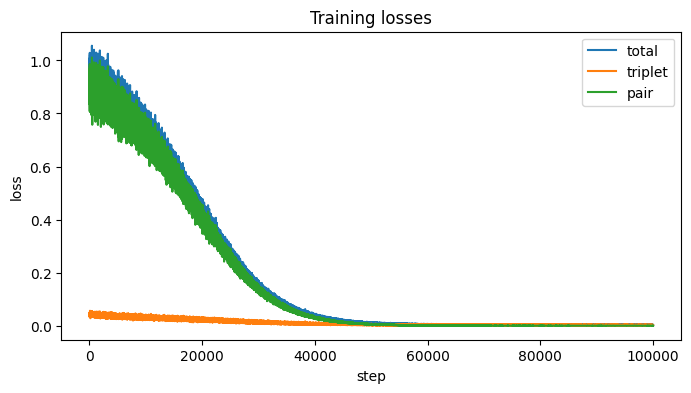

In [53]:
# ============================================================
# 15. Plot training curves
# ============================================================
losses = [x["loss"] for x in history]
triplet_losses = [x["triplet_loss"] for x in history]
pair_losses = [x["pair_loss"] for x in history]

plt.figure(figsize=(8, 4))
plt.plot(losses, label="total")
plt.plot(triplet_losses, label="triplet")
plt.plot(pair_losses, label="pair")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training losses")
plt.show()

## 16. Local pair-correlation evaluation

In [54]:
# ============================================================
# 17. Local pair-correlation evaluation
# ============================================================
@torch.no_grad()
def evaluate_local_pair_correlation(
    model,
    parent,
    depth_edges,
    depth_weight,
    node_ids_a,
    node_ids_b,
    max_tree_dist,
    num_samples=5000,
    device="cpu",
    max_tries=200000,
):
    model.eval()

    dists = []
    neg_sims = []
    tries = 0

    while len(dists) < num_samples and tries < max_tries:
        tries += 1

        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = tree_distance(u, v, parent, depth_edges, depth_weight)
        if d > max_tree_dist:
            continue

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        neg_sims.append(-sim)

    if len(dists) < 10:
        return {
            "num_pairs": len(dists),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    return {
        "num_pairs": len(dists),
        "spearman": float(spearmanr(dists, neg_sims).correlation),
        "pearson": float(pearsonr(dists, neg_sims)[0]),
    }

In [ ]:
for threshold in [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    result = evaluate_local_pair_correlation(
        model,
        parent, depth_edges, depth_weight,
        leaf_ids, leaf_ids,
        max_tree_dist=threshold,
        num_samples=3000,
        device=DEVICE
    )
    print(f"Local leaf-leaf, max_tree_dist={threshold}: {result}")

Local leaf-leaf, max_tree_dist=0.1: {'num_pairs': 217, 'spearman': 0.8962055835663655, 'pearson': 0.9014835098966072}
Local leaf-leaf, max_tree_dist=0.2: {'num_pairs': 710, 'spearman': 0.9630387740154559, 'pearson': 0.9610223753432785}
Local leaf-leaf, max_tree_dist=0.5: {'num_pairs': 3000, 'spearman': 0.9790180254371219, 'pearson': 0.9873806646379188}
Local leaf-leaf, max_tree_dist=1.0: {'num_pairs': 3000, 'spearman': 0.9694803549388704, 'pearson': 0.9846250952602218}
Local leaf-leaf, max_tree_dist=2.0: {'num_pairs': 3000, 'spearman': 0.9825960577309615, 'pearson': 0.980657486821034}
Local leaf-leaf, max_tree_dist=5.0: {'num_pairs': 3000, 'spearman': 0.9760513000056998, 'pearson': 0.9790113282113938}
Local leaf-leaf, max_tree_dist=10.0: {'num_pairs': 3000, 'spearman': 0.9777858600848496, 'pearson': 0.979767688284467}
